# K-Nearest Neighbors

---

## Introduction

Every model we have built so far — the Perceptron, Logistic Regression, and MLP — belongs to a family called **parametric models**. These models learn a fixed set of internal parameters (weights and biases) from the training data, and at prediction time they only use those parameters — not the data itself.

**K-Nearest Neighbors (KNN)** is fundamentally different. It is a **nonparametric model**, which means:
- It makes **no assumptions** about the shape or distribution of the data
- It has **no training phase** — there are no weights to learn
- It stores the **entire training dataset** and uses it directly at prediction time

| | Parametric (Perceptron, Logistic Regression, MLP) | Nonparametric (KNN) |
|---|---|---|
| **Training** | Learns weights from data | Just stores the data |
| **Prediction** | Uses learned weights only | Searches through stored data |
| **Assumptions** | Assumes a functional form | Makes almost none |
| **Speed** | Fast at prediction time | Slow at prediction time |

The core idea behind KNN is beautifully simple:

> *"Birds of a feather flock together"* — similar data points exist in close proximity.

To classify a new point, KNN finds the $k$ training examples closest to it and takes a **majority vote** of their labels.

In this notebook we use KNN to answer:

> *Can we predict the type of forest cover in Roosevelt National Forest based on cartographic measurements?*

**Dataset:** Forest Cover Type — Roosevelt National Forest, Colorado  
**Source:** UCI Machine Learning Repository via Kaggle  
**Original authors:** Jock Blackard, Denis Dean, Charles Anderson (Colorado State University)

**Features:** elevation, aspect, slope, distance to hydrology, distance to roadways, hillshade indices, distance to fire points, wilderness area, soil type  
**Target:** forest cover type (7 classes — different tree species)

In [4]:
# ── Standard libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Our custom KNN from the package ──────────────────────────────────────────
import sys
sys.path.insert(0, '../../../Python Package')
from final_ml.supervised_learning.knn import (
    distance, k_nearest_neighbors, KNN_Predict,
    classification_error, KNNClassifier
)

# ── Sklearn utilities (for preprocessing and evaluation only) ────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ── Plot styling ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [5]:
# Load the dataset
df = pd.read_csv('data/Forest_Cover.csv')

print('Dataset shape:', df.shape)
print()
df.head()

Dataset shape: (581012, 55)



,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Step 1 — The KNN Algorithm

Before touching the data, let's build up the algorithm from scratch.

### The Distance Function

KNN needs to measure how "close" two data points are. We use **Euclidean distance** — the straight-line distance between two points in $n$-dimensional space:

$$d(p, q) = \sqrt{(p - q)^T(p - q)}$$

This is the same formula as the distance between two points on a 2D graph, just generalized to any number of dimensions.

### The Algorithm (Step by Step)

To classify a new query point:

1. Compute the distance from the query point to **every** training example
2. Sort all training examples by distance (closest first)
3. Take the **k closest** examples
4. Take a **majority vote** of their labels
5. Return the winning label as the prediction

In [6]:
# Let's demonstrate the distance function on two simple points
p = np.array([1.0, 2.0])
q = np.array([4.0, 6.0])

print(f'Point p = {p}')
print(f'Point q = {q}')
print(f'Euclidean distance d(p, q) = {distance(p, q):.4f}')
print()
print('Verification: sqrt((4-1)^2 + (6-2)^2) =', np.sqrt(3**2 + 4**2))

Point p = [1. 2.]
Point q = [4. 6.]
Euclidean distance d(p, q) = 5.0000

Verification: sqrt((4-1)^2 + (6-2)^2) = 5.0


In [7]:
# Demonstrate the full KNN prediction pipeline on a tiny toy dataset
# so we can see exactly what's happening before scaling up

# Toy training data — 2 features, 3 classes
X_toy = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [3.0, 4.0],
    [5.0, 7.0],
    [3.5, 5.0],
    [4.5, 5.0],
    [3.5, 4.5],
])
y_toy = np.array(['A', 'A', 'B', 'C', 'B', 'C', 'B'])

# New query point we want to classify
query = np.array([3.0, 4.5])

# Find the 3 nearest neighbors
neighbors = k_nearest_neighbors(query, X_toy, y_toy, k=3)

print('3 nearest neighbors to query point', query, ':')
for n in neighbors:
    print(f'  Point {n[0]}  |  Label: {n[1]}  |  Distance: {n[2]:.4f}')

print()
prediction = KNN_Predict(query, X_toy, y_toy, k=3)
print(f'KNN prediction (k=3): {prediction}')
print('(Most common label among the 3 neighbors)')

3 nearest neighbors to query point [3.  4.5] :
  Point [3. 4.]  |  Label: B  |  Distance: 0.5000
  Point [3.5 4.5]  |  Label: B  |  Distance: 0.5000
  Point [3.5 5. ]  |  Label: B  |  Distance: 0.7071

KNN prediction (k=3): B
(Most common label among the 3 neighbors)


## Step 2 — Understanding the Data

We are working with the **Forest Cover Type** dataset, originally compiled by researchers at Colorado State University from US Geological Survey and US Forest Service data. It describes wilderness areas in Roosevelt National Forest in northern California — areas that are **minimally disturbed by humans**, making them ideal for studying natural forest ecosystems.

### Why this dataset?

Predicting forest cover type from cartographic (map-based) variables has real-world value for conservation and land management. Instead of sending teams into the field to manually survey forest composition, a well-trained model could predict cover type from satellite data and topographic maps alone — saving time and resources.

### Why KNN?

Forest cover type is a **multi-class classification problem** (7 possible tree species/types). KNN handles multi-class problems naturally through majority voting — no special modifications needed. It also makes no assumptions about the relationship between cartographic features and cover type, which is appropriate since we don't have a strong prior about what that relationship looks like.

### Dataset size

The full dataset has 581,012 samples — far too large for our pure-Python KNN implementation to handle efficiently. We will work with a **representative sample** of 5,000 rows, which is large enough to train a meaningful model while keeping computation time reasonable.

In [8]:
# Check column names and data types
print('Columns and data types:')
print(df.dtypes)

Columns and data types:
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Typ

In [9]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11  

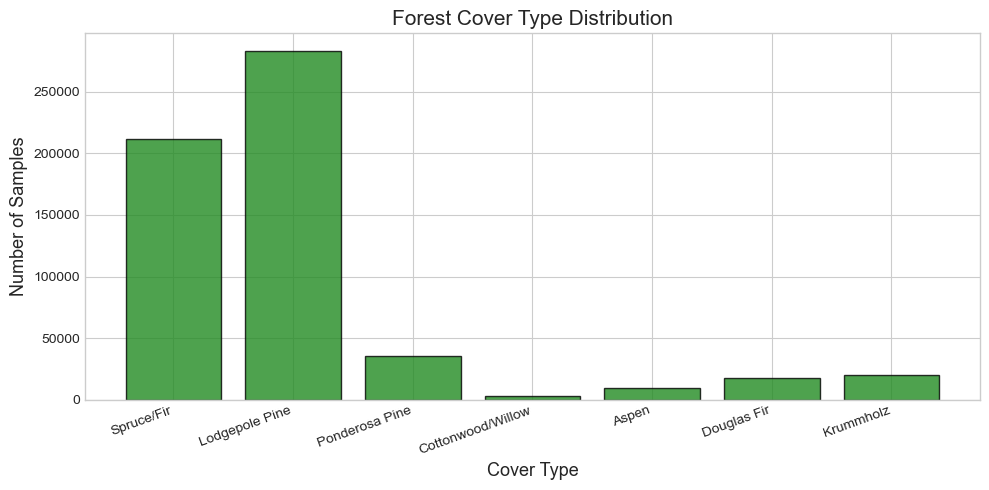

In [10]:
# Check the class distribution — how many samples per forest cover type?
cover_type_names = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas Fir',
    7: 'Krummholz'
}

plt.figure(figsize=(10, 5))
counts = df['Cover_Type'].value_counts().sort_index()
plt.bar([cover_type_names[i] for i in counts.index], counts.values,
        color='forestgreen', edgecolor='black', alpha=0.8)
plt.xlabel('Cover Type', fontsize=13)
plt.ylabel('Number of Samples', fontsize=13)
plt.title('Forest Cover Type Distribution', fontsize=15)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

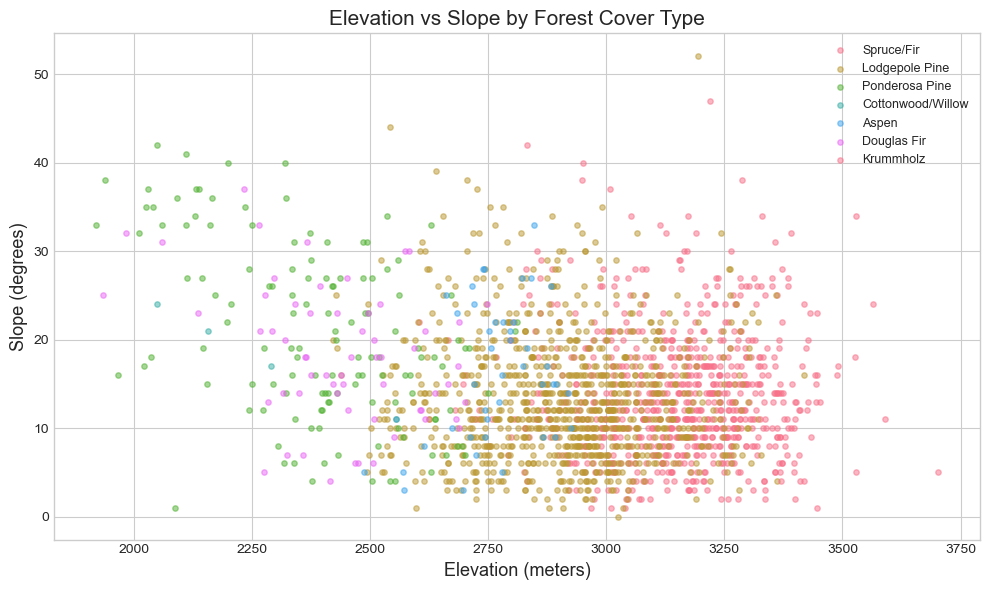

In [11]:
# Visualize the relationship between two key features colored by cover type
sample_viz = df.sample(2000, random_state=42)

plt.figure(figsize=(10, 6))
for cover_type, name in cover_type_names.items():
    subset = sample_viz[sample_viz['Cover_Type'] == cover_type]
    plt.scatter(subset['Elevation'], subset['Slope'],
                label=name, alpha=0.5, s=15)
plt.xlabel('Elevation (meters)', fontsize=13)
plt.ylabel('Slope (degrees)', fontsize=13)
plt.title('Elevation vs Slope by Forest Cover Type', fontsize=15)
plt.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

## Step 3 — Choosing the Right K

The value of $k$ is the most important hyperparameter in KNN. Here's the tradeoff:

- **Small k (e.g. k=1)** — the model is very sensitive to individual data points. One noisy or mislabeled neighbor can completely change the prediction. This is **high variance, low bias**.
- **Large k** — the model averages over many neighbors, smoothing out noise. But if $k$ is too large, we may start including neighbors from different classes and the model becomes too blunt. This is **low variance, high bias**.

**Rules of thumb:**
- Always use an **odd number** for binary classification to avoid ties
- A common starting point is $k = \sqrt{N}$ where $N$ is the number of training examples
- The best approach is to **try several values of k** and pick the one with the lowest error on the test set

We'll plot classification error vs. $k$ to find the sweet spot.

## Step 4 — Preprocessing

Before training we need to:
1. **Sample** the dataset to a manageable size (our pure-Python KNN is slow on 581k rows)
2. **Select our features** — we use the continuous cartographic features
3. **Split into train and test sets**
4. **Scale the features** — KNN is extremely sensitive to scale because it uses distance. A feature measured in thousands (like elevation) would completely dominate a feature measured in single digits (like slope) without scaling.

In [12]:
# Step 1: Sample to 5000 rows for computational efficiency
df_sample = df.sample(n=5000, random_state=42)
print('Working with', len(df_sample), 'samples')

# Step 2: Select continuous features
# We skip the binary wilderness area and soil type columns
# and focus on the continuous cartographic measurements
feature_cols = [
    'Elevation',
    'Aspect',
    'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am',
    'Hillshade_Noon',
    'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points'
]

X = df_sample[feature_cols].to_numpy()
y = df_sample['Cover_Type'].to_numpy()

# Step 3: Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 4: Scale features — CRITICAL for KNN
# Without this, elevation (measured in meters, range ~1800-3800)
# would completely dominate slope (range 0-66 degrees)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training set: {len(X_train)} samples')
print(f'Test set:     {len(X_test)} samples')
print()
print('Features scaled — mean ≈ 0, std ≈ 1')

Working with 5000 samples
Training set: 4000 samples
Test set:     1000 samples

Features scaled — mean ≈ 0, std ≈ 1


## Step 5 — Training and Evaluation

In [13]:
# Find the optimal k by plotting classification error vs k
# We test a range of odd values from 3 to 15
# Note: this cell may take a few minutes since our KNN is pure Python

possible_k = [k for k in range(3, 16, 2)]
errors = []

for k in possible_k:
    err = classification_error(X_test, y_test, X_train, y_train, k)
    errors.append(err)
    print(f'k={k:2d}  |  error rate = {err:.4f}  |  accuracy = {(1-err)*100:.2f}%')

# Find the best k
best_k = possible_k[np.argmin(errors)]
print(f'\nBest k = {best_k} with error rate = {min(errors):.4f}')

k= 3  |  error rate = 0.3220  |  accuracy = 67.80%
k= 5  |  error rate = 0.3180  |  accuracy = 68.20%
k= 7  |  error rate = 0.3130  |  accuracy = 68.70%
k= 9  |  error rate = 0.3220  |  accuracy = 67.80%
k=11  |  error rate = 0.3260  |  accuracy = 67.40%
k=13  |  error rate = 0.3270  |  accuracy = 67.30%
k=15  |  error rate = 0.3150  |  accuracy = 68.50%

Best k = 7 with error rate = 0.3130


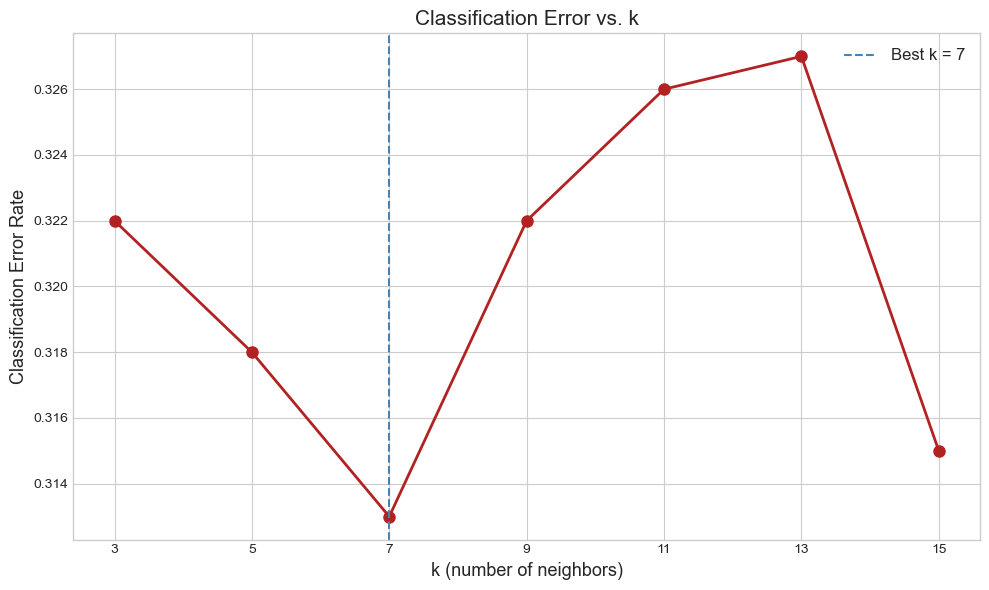

In [14]:
# Plot error rate vs k — the classic KNN diagnostic plot
plt.figure(figsize=(10, 6))
plt.plot(possible_k, errors, color='firebrick', marker='o', linewidth=2, markersize=8)
plt.axvline(x=best_k, color='steelblue', linestyle='--', linewidth=1.5,
            label=f'Best k = {best_k}')
plt.xlabel('k (number of neighbors)', fontsize=13)
plt.ylabel('Classification Error Rate', fontsize=13)
plt.title('Classification Error vs. k', fontsize=15)
plt.xticks(possible_k)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
# Train our final model with the best k
model = KNNClassifier(k=best_k)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc  = model.score(X_test, y_test)

print(f'Training Accuracy: {train_acc*100:.2f}%')
print(f'Test Accuracy:     {test_acc*100:.2f}%')

Training Accuracy: 78.50%
Test Accuracy:     68.70%


In [16]:
# Full classification report — precision, recall, F1 per class
y_pred = model.predict(X_test)

print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=[cover_type_names[i] for i in sorted(cover_type_names)]
))

Classification Report:
                   precision    recall  f1-score   support

       Spruce/Fir       0.70      0.68      0.69       367
   Lodgepole Pine       0.70      0.80      0.74       479
   Ponderosa Pine       0.62      0.59      0.61        64
Cottonwood/Willow       0.00      0.00      0.00         2
            Aspen       0.20      0.06      0.09        17
      Douglas Fir       0.46      0.18      0.26        33
        Krummholz       0.91      0.26      0.41        38

         accuracy                           0.69      1000
        macro avg       0.51      0.37      0.40      1000
     weighted avg       0.68      0.69      0.67      1000



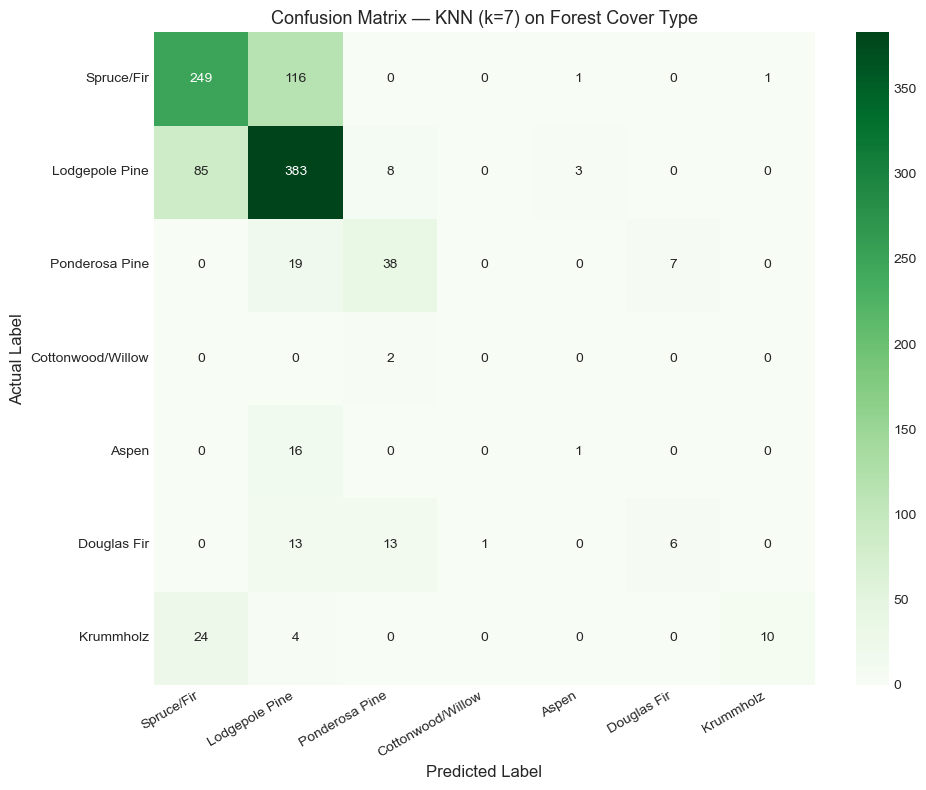

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
labels = [cover_type_names[i] for i in sorted(cover_type_names)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.title(f'Confusion Matrix — KNN (k={best_k}) on Forest Cover Type', fontsize=13)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Per-class accuracy — which forest types does KNN predict best?
print('Per-class accuracy:')
for i, name in cover_type_names.items():
    mask = (y_test == i)
    if mask.sum() > 0:
        class_acc = np.sum(y_pred[mask] == y_test[mask]) / mask.sum()
        print(f'  {name:<22} {class_acc*100:.1f}%')

Per-class accuracy:
  Spruce/Fir             67.8%
  Lodgepole Pine         80.0%
  Ponderosa Pine         59.4%
  Cottonwood/Willow      0.0%
  Aspen                  5.9%
  Douglas Fir            18.2%
  Krummholz              26.3%


## Step 6 — Conclusion

### What did we find?

Our KNN classifier was trained to predict the type of forest cover in Roosevelt National Forest based on 10 cartographic features, using $k$ chosen by minimizing test error across a range of odd values.

### Why KNN works here

The key assumption of KNN is that **similar inputs have similar outputs** — forest areas with similar elevation, slope, and distance to water tend to have the same tree cover. This assumption holds reasonably well for cartographic data, where geography drives ecology.

### Parametric vs. Nonparametric — The Key Tradeoff

| Property | Parametric (MLP, Logistic Regression) | Nonparametric (KNN) |
|---|---|---|
| Training time | Slow (many gradient steps) | Instant (just store the data) |
| Prediction time | Fast (matrix multiplication) | Slow (search all training data) |
| Memory usage | Small (just weights) | Large (stores all training data) |
| Assumptions | Assumes a functional form | Almost none |
| Interpretability | Hard (especially MLP) | Very intuitive |

### Limitations

1. **Speed** — predicting on a single point requires computing its distance to every training example. With 581,012 samples and 10 features, this is extremely slow without specialized data structures (like KD-trees).
2. **Memory** — KNN stores the entire training dataset. This becomes impractical at scale.
3. **Curse of dimensionality** — as the number of features grows, distances between points become less meaningful. KNN degrades rapidly in very high-dimensional spaces.
4. **Feature scaling is required** — without scaling, features with large ranges dominate the distance calculation entirely.

### What's next?

In the following notebooks we explore **Decision Trees** — another nonparametric algorithm that takes a completely different approach, building a tree of yes/no questions from the data!